# SETUP

In [ ]:
import pandas as pd
import numpy as np
import random
import json
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import re
from tqdm import tqdm
import cv2
import os
import string
from collections import Counter
from functools import partial
from textwrap import wrap
import textwrap as tw
from warnings import filterwarnings
import gc

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW, AdamW
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torch.nn.utils import clip_grad_norm_

from torchvision.transforms import v2
from torchvision.models import inception_v3, Inception_V3_Weights, ResNet50_Weights, resnet50
import evaluate
from pycocoevalcap.cider.cider import Cider
from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig, Seq2SeqTrainingArguments, Seq2SeqTrainer, GPT2Tokenizer, Dinov2Model, get_scheduler, AutoProcessor, AutoModelForCausalLM, BlipProcessor, BlipForConditionalGeneration
from peft import LoraConfig, get_peft_model

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score

filterwarnings("ignore")
SEED=42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
set_seed(SEED)


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


# DATASET

In [5]:
TRAIN_METADATA_PATH = "/kaggle/input/datasets/frzzz090/metadata-vw/Train.csv"
VAL_METADATA_PATH = "/kaggle/input/datasets/frzzz090/metadata-vw/Val.csv"
TEST_ANNOTATION_PATH = "/kaggle/input/datasets/frzzz090/vizwizz-ds/test.json"
TRAIN_IMG_PATH = "/kaggle/input/datasets/frzzz090/vizwizz-ds/train/train"
VAL_IMG_PATH = "/kaggle/input/datasets/frzzz090/vizwizz-ds/val/val"

In [6]:
train_df = pd.read_csv(TRAIN_METADATA_PATH)
print(f"Number of training samples: {len(train_df)}")
display(train_df.head())

val_df = pd.read_csv(VAL_METADATA_PATH)
print(f"\nNumber of validation samples: {len(val_df)}")
display(val_df.head())

with open(TEST_ANNOTATION_PATH, "r") as f:
    test_data = json.load(f)
test_df = pd.DataFrame(test_data['images'])
print(f"\nNumber of test samples: {len(test_df)}")
display(test_df.head())

Number of training samples: 117155


,caption,image_id,is_precanned,is_rejected,id,text_detected,caption_id
0,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True,INI ADALAH WADAH DAUN BASIL YANG MENUNJUKKAN B...
1,A green and white plastic condiment bottle con...,0,False,False,1,True,Botol bumbu plastik berwarna hijau dan putih b...
2,Quality issues are too severe to recognize vis...,0,True,True,2,True,Masalah kualitasnya terlalu parah sehingga kon...
3,A bottle of spices in a plastic container layi...,0,False,False,3,True,Sebotol bumbu dalam wadah plastik tergeletak d...
4,some basil leaves in a container on a counter,0,False,False,4,True,beberapa lembar daun basil dalam wadah di atas...



Number of validation samples: 38750


,caption,image_id,is_precanned,is_rejected,id,text_detected,caption_id
0,A computer screen shows a repair prompt on the...,23431,False,False,117155,True,Layar komputer menampilkan perintah perbaikan.
1,a computer screen with a repair automatically ...,23431,False,False,117156,True,Layar komputer dengan pesan perbaikan yang mun...
2,partial computer screen showing the need of re...,23431,False,False,117157,True,Sebagian layar komputer menunjukkan perlunya p...
3,Part of a computer monitor showing a computer ...,23431,False,False,117158,True,Bagian dari monitor komputer yang menampilkan ...
4,The top of a laptop with a blue background and...,23431,False,False,117159,True,Bagian atas laptop dengan latar belakang biru ...



Number of test samples: 8000


,file_name,vizwiz_url,id,text_detected
0,VizWiz_test_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31181,True
1,VizWiz_test_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31182,False
2,VizWiz_test_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31183,True
3,VizWiz_test_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31184,True
4,VizWiz_test_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31185,True


In [7]:
unq_id = sorted([int(i.split("_")[2].split(".")[0]) for i in os.listdir(VAL_IMG_PATH)])
max_val_id = max(unq_id)
new_val_id = [i for i in range(max_val_id + 1) for j in range(5)]
val_df['image_id'] = new_val_id

In [8]:
print("Total missing value in train:")
display(train_df.isnull().sum())

print("\nTotal missing value in val:")
display(val_df.isnull().sum())

print("\nTotal missing value in test:")
display(test_df.isnull().sum())

Total missing value in train:


caption          0
image_id         0
is_precanned     0
is_rejected      0
id               0
text_detected    0
caption_id       0
dtype: int64


Total missing value in val:


caption          0
image_id         0
is_precanned     0
is_rejected      0
id               0
text_detected    0
caption_id       0
dtype: int64


Total missing value in test:


file_name        0
vizwiz_url       0
id               0
text_detected    0
dtype: int64

In [9]:
print(f"Total duplicate in train: {train_df.duplicated().sum()}")
print(f"Total duplicate in val: {val_df.duplicated().sum()}")
print(f"Total duplicate in test: {val_df.duplicated().sum()}")

Total duplicate in train: 0
Total duplicate in val: 0
Total duplicate in test: 0


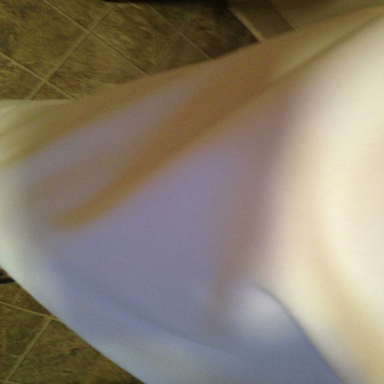

In [10]:
def display_single_image(image_id):
    image_path = os.path.join(TRAIN_IMG_PATH, f"VizWiz_train_{image_id:08d}.jpg")
    image = Image.open(image_path).resize((384, 384))
    display(image)
display_single_image(train_df.loc[train_df['image_id'] == 15, 'image_id'].values[0])

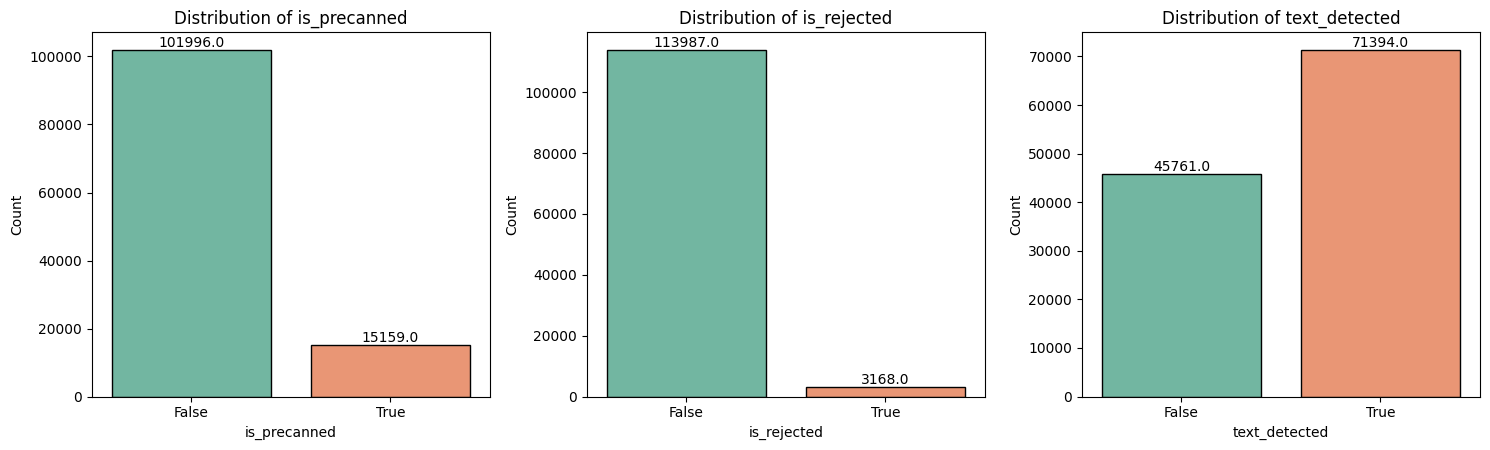

In [11]:
def cols_distribution(df, columns):
    length = len(columns)
    cols = 3
    rows = length // cols + (length % cols > 0)
    plt.figure(figsize=(5 * cols, 5 * rows))
    for i, col in enumerate(columns):
        plt.subplot(rows, cols, i + 1)
        ax =sns.countplot(x=col, data=df, palette='Set2', edgecolor='black')
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        for p in ax.patches:
            ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
cols_distribution(train_df, ['is_precanned', 'is_rejected', 'text_detected'])

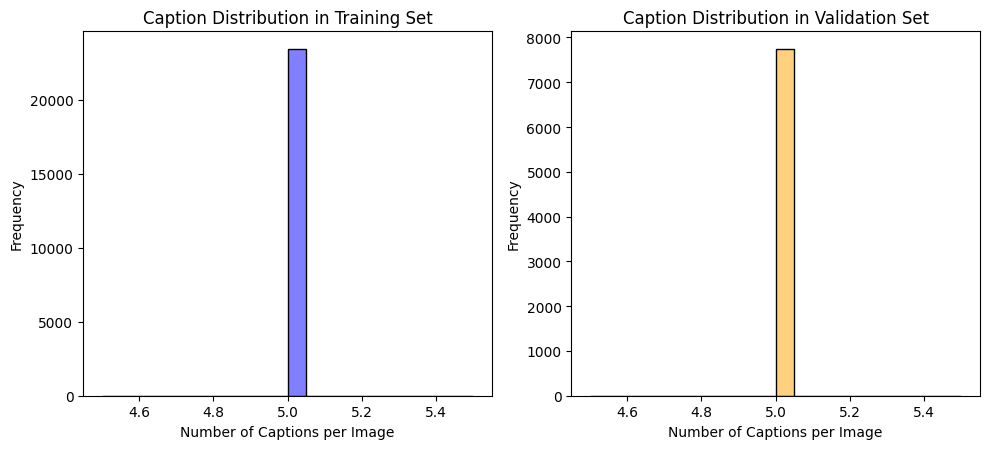

In [12]:
def captions_distribution(train, val):
    cols, rows = 2, 1
    plt.figure(figsize=(5 * cols, 5 * rows))
    plt.subplot(rows, cols, 1)
    train_dist = train.groupby('image_id')['caption'].count()
    sns.histplot(train_dist, bins=20, kde=True, color='blue', edgecolor='black')
    plt.title("Caption Distribution in Training Set")
    plt.xlabel("Number of Captions per Image")
    plt.ylabel("Frequency")
    plt.subplot(rows, cols, 2)
    val_dist = val.groupby('image_id')['caption'].count()
    sns.histplot(val_dist, bins=20, kde=True, color='orange', edgecolor='black')
    plt.title("Caption Distribution in Validation Set")
    plt.xlabel("Number of Captions per Image")
    plt.ylabel("Frequency")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
captions_distribution(train_df, val_df)


Image ID: 20952


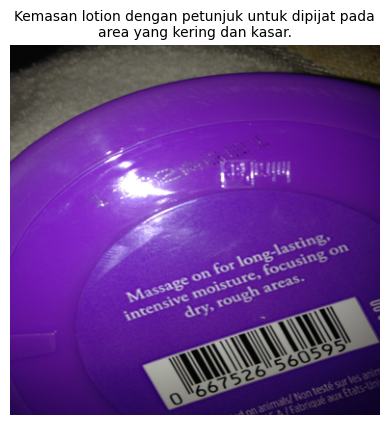

Image ID: 3648


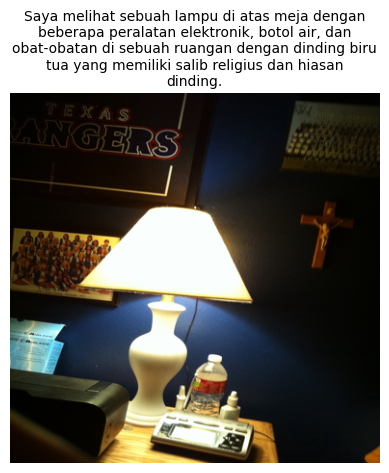

Image ID: 819


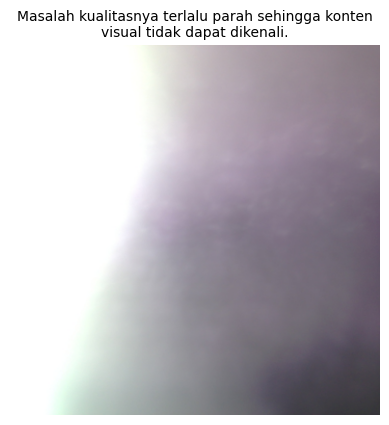

Image ID: 9012


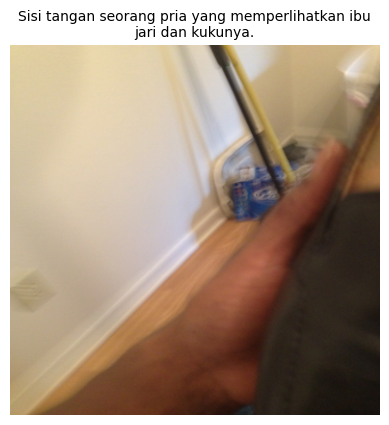

Image ID: 8024


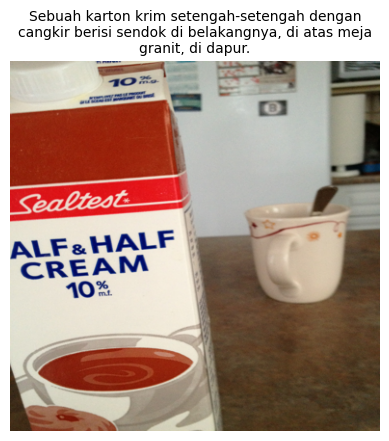

In [13]:
def display_image_captions(df, n_samples=5):
    random_idxs = random.sample(list(df['image_id'].unique()), n_samples)
    for idx in random_idxs:
        image_path = os.path.join(TRAIN_IMG_PATH, f"VizWiz_train_{idx:08d}.jpg")
        image = Image.open(image_path).resize((384, 384))
        captions = df[df['image_id'] == idx]['caption_id'].values[0]
        print(f"Image ID: {idx}")
        plt.imshow(image)
        plt.axis('off')
        plt.title("\n".join(wrap(captions, width=50)), fontsize=10)
        plt.show()
display_image_captions(train_df, n_samples=5)


In [14]:
def preprocess_caption(caption):
    caption = caption.lower()
    punc = string.punctuation.replace("'", "")
    caption = re.sub(f"[{re.escape(punc)}]", " ", caption)
    caption = re.sub(r'\s+', ' ', caption).strip()
    caption = caption + "."
    return caption
train_df['cleaned_caption'] = train_df['caption_id'].apply(preprocess_caption)
val_df['cleaned_caption'] = val_df['caption_id'].apply(preprocess_caption)
display(train_df[['caption', 'cleaned_caption']].head())

,caption,cleaned_caption
0,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,ini adalah wadah daun basil yang menunjukkan b...
1,A green and white plastic condiment bottle con...,botol bumbu plastik berwarna hijau dan putih b...
2,Quality issues are too severe to recognize vis...,masalah kualitasnya terlalu parah sehingga kon...
3,A bottle of spices in a plastic container layi...,sebotol bumbu dalam wadah plastik tergeletak d...
4,some basil leaves in a container on a counter,beberapa lembar daun basil dalam wadah di atas...


In [15]:
train_df['image_id'] = train_df['image_id'].apply(lambda x: f"VizWiz_train_{x:08d}.jpg")
val_df['image_id'] = val_df['image_id'].apply(lambda x: f"VizWiz_val_{x:08d}.jpg")

In [16]:
max_len_train = train_df['cleaned_caption'].apply(lambda x: len(x.split())).max()
max_len_val = val_df['cleaned_caption'].apply(lambda x: len(x.split())).max()
max_len = max(max_len_train, max_len_val)
print(f"Max caption length in training set: {max_len_train}")
print(f"Max caption length in validation set: {max_len_val}")
print(f"Overall max caption length: {max_len}")

Max caption length in training set: 106
Max caption length in validation set: 145
Overall max caption length: 145


In [17]:
# pakai 1 img aj
grouped_captions_val = val_df.groupby('image_id')['cleaned_caption'].apply(list).to_dict()
grouped_captions_train = train_df.groupby('image_id')['cleaned_caption'].apply(list).to_dict()
val_df = val_df.drop_duplicates(subset=['image_id']).reset_index(drop=True)
val_df.shape

(7750, 8)

In [18]:
def print_param(model, stage_name=""):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    all_params = sum(p.numel() for p in model.parameters())
    print(f"--- {stage_name} ---")
    print(f"Trainable params : {trainable_params:,}")
    print(f"Total params     : {all_params:,}")
    print(f"% Trainable      : {100 * trainable_params / all_params:.4f}%\n")

# MODEL

## BLIP

In [19]:
gc.collect()
torch.cuda.empty_cache()

In [20]:
class BlipImageCaptionDataset(Dataset):
    def __init__(self, df, processor, images_dir, grouped_captions=None, transform=None):
        self.df = df
        self.processor = processor
        self.images_dir = images_dir
        self.grouped_captions = grouped_captions
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_id = self.df.iloc[idx]['image_id']
        caption = self.df.iloc[idx]['cleaned_caption'] 
        grouped_captions = self.grouped_captions[image_id] if self.grouped_captions is not None else None

        image_path = os.path.join(self.images_dir, image_id)
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "caption": caption,
            "grouped_captions": grouped_captions
        }
    
def collate_fn(batch, processor, max_len=max_len): 
    images = [item['image'] for item in batch] 
    captions = [item['caption'] for item in batch]
    grouped_captions = [item['grouped_captions'] for item in batch]

    inputs = processor(
        images=images,
        text=captions,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )

    labels = inputs['input_ids'].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100

    inputs['labels'] = labels
    inputs['grouped_captions'] = grouped_captions

    return inputs


train_aug = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),             
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3, hue=0.1),
    v2.RandomAutocontrast(p=0.5)
])

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

train_dataset = BlipImageCaptionDataset(
    df=train_df,
    processor=processor,
    images_dir=TRAIN_IMG_PATH,
    grouped_captions=grouped_captions_train,
    transform=train_aug,
)

val_dataset = BlipImageCaptionDataset(
    df=val_df,
    processor=processor,
    images_dir=VAL_IMG_PATH,
    grouped_captions=grouped_captions_val,
)

BATCH_SIZE = 8 

collate = partial(collate_fn, processor=processor, max_len=max_len)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate, 
    num_workers=4, 
    pin_memory=True, 
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate, 
    num_workers=4, 
    pin_memory=True, 
)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [21]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(DEVICE)
print_param(model, "BLIP Params")

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

--- BLIP Params ---
Trainable params : 247,444,600
Total params     : 247,444,600
% Trainable      : 100.0000%



In [ ]:
metric_bleu = evaluate.load("bleu")
metric_rouge = evaluate.load("rouge")
metric_meteor = evaluate.load("meteor")
metric_bertscore = evaluate.load("bertscore")

EPOCHS = 3

optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5) 

num_training_steps = EPOCHS * len(train_loader) 

scheduler = get_scheduler(
    name="cosine",
    optimizer=optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)

scaler = GradScaler()

def train_epoch(model, dataloader, optimizer, scheduler, device, scaler):
    model.train()
    total_loss = 0

    for batch in tqdm(dataloader, desc="Training"):
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'grouped_captions'}

        optimizer.zero_grad()

        with autocast():
            outputs = model(**inputs)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def eval_epoch(model, dataloader, device, processor, max_gen_len=32):
    model.eval()
    total_loss = 0

    all_preds = []
    all_refs = []
    sample_generated = ""
    sample_truth = ""

    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="Evaluating")):
            inputs = {k: v.to(device) for k, v in batch.items() if k != 'grouped_captions'}
            grouped_captions = batch['grouped_captions'] 

            with autocast():
                outputs = model(**inputs)
                loss = outputs.loss
            total_loss += loss.item()

            generated_ids = model.generate(
                pixel_values=inputs['pixel_values'], 
                max_new_tokens=max_gen_len, 
                num_beams=3
            )
            
            pred_captions = processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            pred_captions = [pred.strip() if pred.strip() != "" else "unk" for pred in pred_captions] 
            
            all_preds.extend(pred_captions)
            all_refs.extend(grouped_captions) 

            if i == 0:
                sample_generated = pred_captions[0]
                sample_truth = grouped_captions[0][0]

    bleu_score = metric_bleu.compute(predictions=all_preds, references=all_refs)['bleu']
    rouge_score = metric_rouge.compute(predictions=all_preds, references=all_refs)['rougeL']
    meteor_score = metric_meteor.compute(predictions=all_preds, references=all_refs)['meteor']
    
    bertscore_results = metric_bertscore.compute(predictions=all_preds, references=all_refs, lang="id", device=device)
    bert_score_f1_avg = np.mean(bertscore_results['f1'])

    print(f"\n[Validation Result]")
    print(f"Pred  : {sample_generated}")
    print(f"Truth : {sample_truth} (Salah satu variasi)")
    print("-" * 50)

    return total_loss / len(dataloader), bleu_score, rouge_score, meteor_score, bert_score_f1_avg


best_val_loss = float('inf')
best_bleu_score = -1.0
model_save_path = 'best_blip_model' 

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE, scaler)
    
    val_loss, val_bleu, val_rouge, val_meteor, val_bert = eval_epoch(
        model, val_loader, DEVICE, processor, max_gen_len=32
    )

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val BLEU: {val_bleu:.4f} | Val ROUGE: {val_rouge:.4f} | Val METEOR: {val_meteor:.4f} | Val BERTScore: {val_bert:.4f}")

    if val_bleu > best_bleu_score:
        best_bleu_score = val_bleu
        best_val_loss = val_loss
        model.save_pretrained(model_save_path)
        processor.save_pretrained(model_save_path)
        print(">>> Model saved (New Best BLEU Score)!")
        
    elif val_bleu == best_bleu_score and val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_pretrained(model_save_path)
        processor.save_pretrained(model_save_path)
        print(">>> Model saved based on improved loss!")

    print("=" * 60)

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...



Epoch 1/3


Evaluating: 100%|██████████| 969/969 [25:56<00:00,  1.61s/it]


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

>>> Model saved (New Best BLEU Score)!

Epoch 3/3


Evaluating: 100%|██████████| 969/969 [26:20<00:00,  1.63s/it]



[Validation Result]
Pred  : masalah kualitasnya terlalu parah sehingga konten visual tidak dapat dikenali.
Truth : layar komputer menampilkan perintah perbaikan. (Salah satu variasi)
--------------------------------------------------
Train Loss: 0.4554
Val Loss: 1.3291 | Val BLEU: 0.4059 | Val ROUGE: 0.5033 | Val METEOR: 0.5080 | Val BERTScore: 0.8497


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

>>> Model saved (New Best BLEU Score)!


In [ ]:
model_save_path = '../data/best_blip_model'
model = BlipForConditionalGeneration.from_pretrained(model_save_path).to(DEVICE)
processor = BlipProcessor.from_pretrained(model_save_path)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
voc = dict()
for image_id, captions in tqdm(grouped_captions_val.items(), desc="Creating Vocabulary Dictionary"):
    unqs = set()
    for cap in captions:
        unqs.update(cap.split())
    sents = " ".join(unqs)
    
    cap_tokens = set(w.lower().strip(".,!?;:()'\"") for w in sents.split())
    
    voc[image_id] = cap_tokens



Creating Vocabulary Dictionary: 100%|██████████| 7750/7750 [00:00<00:00, 42647.58it/s]


In [ ]:
generated_captions = dict()

model.eval()

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(val_loader, desc="Evaluating")):
        inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != 'grouped_captions'}
        grouped_captions = batch['grouped_captions'] 

        generated_ids = model.generate(
            pixel_values=inputs['pixel_values'], 
            max_new_tokens=32, 
            num_beams=3
        )
        
        pred_captions = processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        pred_captions = [pred.strip() if pred.strip() != "" else "unk" for pred in pred_captions] 
        batch_size = inputs['pixel_values'].shape[0] 
        for i in range(batch_size):
            generated_captions[f'VizWiz_val_{batch_idx * batch_size + i:08d}.jpg'] = pred_captions[i]
            
                

Evaluating: 100%|██████████| 485/485 [17:53<00:00,  2.21s/it]


In [ ]:
gts = {}
res = {}

for img_id, gt_captions in grouped_captions_val.items():
    if img_id in generated_captions:
        gts[img_id] = gt_captions
        
        pred = generated_captions[img_id]
        if isinstance(pred, str):
            res[img_id] = [pred]
        else:
            res[img_id] = pred

cider_scorer = Cider()
avg_score, individual_scores = cider_scorer.compute_score(gts, res)

print(f"\nSkor CIDEr Rata-rata (Seluruh Dataset): {avg_score:.4f}\n")


Skor CIDEr Rata-rata (Seluruh Dataset): 1.4697

